# 04. Diagnostic Analysis

## Objective

This notebook performs the formal diagnostic analysis of repeat-purchase
behaviour.

The analysis focuses on the two primary hypotheses defined in the project:

- **H1:** Customers whose first order was delivered late have a lower
  repeat-purchase rate.
- **H2:** Higher first-order freight burden is associated with lower
  repeat purchase.

The notebook uses the customer-level feature-engineered table prepared in
Notebook 03.

Formal tests are reported with effect sizes and 95% confidence intervals.
The results should be interpreted as associations, not proof of causality.

## 1. Connect to DuckDB

Open the DuckDB database used by the analytical workflow.

The database is expected under `04_DuckDB`.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd().parent
DUCKDB_PATH = PROJECT_ROOT / "04_DuckDB" / "olist_capstone.duckdb"
OUTPUT_DIR = PROJECT_ROOT / "02_Data" / "04_Diagnostic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DUCKDB_PATH.exists():
    raise FileNotFoundError(
        f"DuckDB database not found: {DUCKDB_PATH}"
    )

con = duckdb.connect(str(DUCKDB_PATH))

print(f"DuckDB version: {duckdb.__version__}")
print(f"Database: {DUCKDB_PATH}")

DuckDB version: 1.5.5
Database: d:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\04_DuckDB\olist_capstone.duckdb


## 2. Confirm the Diagnostic Dataset

The diagnostic analysis is performed at customer level so that each customer
contributes one observation.

Before testing the hypotheses, verify the population size, uniqueness and
availability of the main variables.

In [2]:
required_columns = [
    "customer_unique_id",
    "is_repeat_customer",
    "first_order_late_flag",
    "first_order_freight_ratio",
    "first_order_value",
    "first_order_freight",
    "first_order_installments",
    "freight_burden_band",
    "value_tier"
]

schema = con.sql("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'customer_level_featured'
ORDER BY ordinal_position
""").df()

available_columns = set(schema["column_name"])

missing_columns = [
    c for c in required_columns
    if c not in available_columns
]

if missing_columns:
    raise ValueError(
        f"Required columns missing from customer_level_featured: "
        f"{missing_columns}"
    )

population = con.sql("""
SELECT
    COUNT(*) AS customers,
    COUNT(DISTINCT customer_unique_id) AS unique_customers,
    COUNT(*) - COUNT(DISTINCT customer_unique_id)
        AS duplicate_customer_rows,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
""").df()

display(population)

,customers,unique_customers,duplicate_customer_rows,repeat_customers,repeat_rate_pct
0,93254,93254,0,2877.0,3.085122


## 3. Data Quality Check Before Testing

Check missing values in the variables used for the formal analysis.

Rows with missing values in a variable required for a specific test are
excluded only from that test. The overall analytical population is not
silently changed.

In [3]:
quality = con.sql("""
SELECT
    COUNT(*) AS customers,

    SUM(CASE WHEN is_repeat_customer IS NULL THEN 1 ELSE 0 END)
        AS missing_target,

    SUM(CASE WHEN first_order_late_flag IS NULL THEN 1 ELSE 0 END)
        AS missing_late_flag,

    SUM(CASE WHEN first_order_freight_ratio IS NULL THEN 1 ELSE 0 END)
        AS missing_freight_ratio,

    SUM(CASE WHEN first_order_freight IS NULL THEN 1 ELSE 0 END)
        AS missing_freight,

    SUM(CASE WHEN first_order_value IS NULL THEN 1 ELSE 0 END)
        AS missing_order_value
FROM customer_level_featured
""").df()

display(quality)

,customers,missing_target,missing_late_flag,missing_freight_ratio,missing_freight,missing_order_value
0,93254,0.0,0.0,0.0,0.0,0.0


# H1 — First-Order Delivery Lateness and Repeat Purchase

## Hypothesis

**H1:** Customers whose first order was delivered late have a lower
repeat-purchase rate than customers whose first order was on time or early.

The first step is a descriptive comparison. Statistical testing follows.

In [4]:
h1_descriptive = con.sql("""
SELECT
    CASE
        WHEN first_order_late_flag = 1 THEN 'Late'
        WHEN first_order_late_flag = 0 THEN 'On-time / early'
    END AS delivery_group,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    AVG(is_repeat_customer) AS repeat_rate,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
WHERE first_order_late_flag IS NOT NULL
  AND is_repeat_customer IS NOT NULL
GROUP BY first_order_late_flag
ORDER BY first_order_late_flag
""").df()

display(h1_descriptive)

,delivery_group,customers,repeat_customers,repeat_rate,repeat_rate_pct
0,On-time / early,85662,2683.0,0.031321,3.132077
1,Late,7592,194.0,0.025553,2.555321


## 4. H1 — Chi-Square Test

A chi-square test of independence is used to test whether delivery status
and repeat-purchase status are associated.

The null hypothesis is that the two categorical variables are independent.

In [5]:
h1_data = con.sql("""
SELECT
    first_order_late_flag,
    is_repeat_customer
FROM customer_level_featured
WHERE first_order_late_flag IS NOT NULL
  AND is_repeat_customer IS NOT NULL
""").df()

h1_table = pd.crosstab(
    h1_data["first_order_late_flag"],
    h1_data["is_repeat_customer"]
)

chi2, p_value, dof, expected = chi2_contingency(h1_table)

h1_result = pd.DataFrame({
    "chi_square": [chi2],
    "degrees_of_freedom": [dof],
    "p_value": [p_value]
})

display(h1_table)
display(h1_result)

is_repeat_customer,0,1
first_order_late_flag,,
0,82979,2683
1,7398,194


,chi_square,degrees_of_freedom,p_value
0,7.567164,1,0.005944


## 5. H1 — Effect Size and 95% Confidence Interval

The main business effect is the difference in repeat-purchase rates between
late and on-time/early first-order groups.

The odds ratio is also reported because it gives an interpretable measure of
the relative odds of repeat purchase.

In [6]:
late = h1_data[h1_data["first_order_late_flag"] == 1]
on_time = h1_data[h1_data["first_order_late_flag"] == 0]

late_n = len(late)
on_time_n = len(on_time)

late_repeat = int(late["is_repeat_customer"].sum())
on_time_repeat = int(on_time["is_repeat_customer"].sum())

late_rate = late_repeat / late_n
on_time_rate = on_time_repeat / on_time_n

rate_difference = late_rate - on_time_rate

# Confidence interval for difference in two proportions.
count = np.array([late_repeat, on_time_repeat])
nobs = np.array([late_n, on_time_n])

z_stat, z_p = proportions_ztest(count, nobs)

se = np.sqrt(
    late_rate * (1 - late_rate) / late_n
    + on_time_rate * (1 - on_time_rate) / on_time_n
)

ci_low = rate_difference - 1.96 * se
ci_high = rate_difference + 1.96 * se

# Odds ratio: late vs on-time/early.
late_nonrepeat = late_n - late_repeat
on_time_nonrepeat = on_time_n - on_time_repeat

odds_ratio = (
    (late_repeat / late_nonrepeat)
    / (on_time_repeat / on_time_nonrepeat)
)

h1_effect = pd.DataFrame({
    "late_repeat_rate_pct": [late_rate * 100],
    "on_time_repeat_rate_pct": [on_time_rate * 100],
    "difference_late_minus_on_time_pp": [rate_difference * 100],
    "difference_95ci_low_pp": [ci_low * 100],
    "difference_95ci_high_pp": [ci_high * 100],
    "odds_ratio_late_vs_on_time": [odds_ratio],
    "z_statistic": [z_stat],
    "two_proportion_p_value": [z_p],
    "chi_square_p_value": [p_value]
})

display(h1_effect)

,late_repeat_rate_pct,on_time_repeat_rate_pct,difference_late_minus_on_time_pp,difference_95ci_low_pp,difference_95ci_high_pp,odds_ratio_late_vs_on_time,z_statistic,two_proportion_p_value,chi_square_p_value
0,2.555321,3.132077,-0.576756,-0.950391,-0.203121,0.811026,-2.785474,0.005345,0.005944


### H1 — Visualising the Effect

The chart below shows the same comparison as the table above, with the
95% confidence interval as error bars. Colour is used deliberately: the
late-delivery bar is shown in red **because the chi-square test above is
significant at p < 0.05** — if it were not significant, both bars would
be shown in the same neutral grey, so colour is never used to suggest an
effect the statistics don't support.


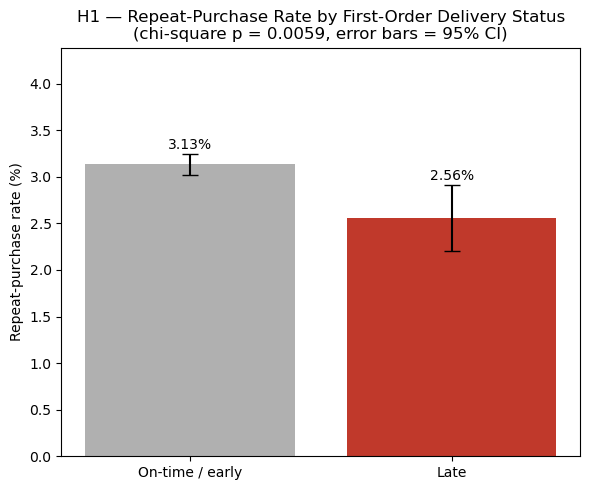

In [7]:
import matplotlib.pyplot as plt

NEUTRAL = "#B0B0B0"
SIGNAL = "#C0392B"

# Standard errors for each group's own proportion (for the error bars --
# distinct from the standard error of the DIFFERENCE computed earlier).
late_se = np.sqrt(late_rate * (1 - late_rate) / late_n)
on_time_se = np.sqrt(on_time_rate * (1 - on_time_rate) / on_time_n)

groups = ["On-time / early", "Late"]
rates = [on_time_rate * 100, late_rate * 100]
errors = [1.96 * on_time_se * 100, 1.96 * late_se * 100]

is_significant = p_value < 0.05
colors = [
    NEUTRAL,
    SIGNAL if is_significant else NEUTRAL,
]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(groups, rates, yerr=errors, capsize=6, color=colors)
ax.set_ylabel("Repeat-purchase rate (%)")
ax.set_title(
    "H1 — Repeat-Purchase Rate by First-Order Delivery Status\n"
    f"(chi-square p = {p_value:.4f}, error bars = 95% CI)"
)
ax.set_ylim(0, max(rates) * 1.4)
for i, (r, e) in enumerate(zip(rates, errors)):
    ax.text(i, r + e + 0.05, f"{r:.2f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 6. H1 — Interpretation

Interpret the result using the observed direction, effect size, confidence
interval and p-value.

A statistically significant result would indicate evidence of an association
between first-order delivery lateness and repeat purchase in this dataset.
It would not establish that lateness directly causes non-repeat behaviour.

In [8]:
alpha = 0.05

if p_value < alpha:
    conclusion = (
        "The chi-square test provides evidence of an association between "
        "first-order delivery status and repeat purchase at the 5% level."
    )
else:
    conclusion = (
        "The chi-square test does not provide sufficient evidence of an "
        "association between first-order delivery status and repeat purchase "
        "at the 5% level."
    )

print(conclusion)
print(
    f"Repeat-rate difference (late - on-time/early): "
    f"{rate_difference * 100:.2f} percentage points."
)
print(
    f"95% CI for the difference: "
    f"{ci_low * 100:.2f} to {ci_high * 100:.2f} percentage points."
)
print(
    f"Odds ratio (late vs on-time/early): {odds_ratio:.3f}"
)

The chi-square test provides evidence of an association between first-order delivery status and repeat purchase at the 5% level.
Repeat-rate difference (late - on-time/early): -0.58 percentage points.
95% CI for the difference: -0.95 to -0.20 percentage points.
Odds ratio (late vs on-time/early): 0.811


# H2 — Freight Burden and Repeat Purchase

## Hypothesis

**H2:** Higher first-order freight burden is associated with lower
repeat purchase.

The project uses first-order freight relative to first-order order value as
the main freight-burden measure.

The descriptive quartile bands are retained from Notebook 03.

In [9]:
h2_descriptive = con.sql("""
SELECT
    freight_burden_band,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct,
    AVG(first_order_freight_ratio) AS avg_freight_ratio,
    MEDIAN(first_order_freight_ratio) AS median_freight_ratio
FROM customer_level_featured
WHERE freight_burden_band IS NOT NULL
  AND is_repeat_customer IS NOT NULL
GROUP BY freight_burden_band
ORDER BY
    CASE freight_burden_band
        WHEN 'Low freight burden' THEN 1
        WHEN 'Medium-low freight burden' THEN 2
        WHEN 'Medium-high freight burden' THEN 3
        WHEN 'High freight burden' THEN 4
    END
""").df()

display(h2_descriptive)

,freight_burden_band,customers,repeat_customers,repeat_rate_pct,avg_freight_ratio,median_freight_ratio
0,Low freight burden,23325,737.0,3.159700,0.248957,0.189366
1,Medium-low freight burden,23318,785.0,3.366498,0.332199,0.243573
2,Medium-high freight burden,23302,617.0,2.647841,0.291594,0.205396
3,High freight burden,23309,738.0,3.166159,0.358731,0.265271


## 7. H2 — Low vs High Freight Burden

The primary diagnostic contrast compares the lowest and highest freight
burden groups.

This keeps the formal comparison simple while retaining all four bands in
the descriptive analysis.

In [10]:
h2_data = con.sql("""
SELECT
    freight_burden_band,
    is_repeat_customer,
    first_order_freight_ratio,
    first_order_freight,
    first_order_value
FROM customer_level_featured
WHERE freight_burden_band IN (
    'Low freight burden',
    'High freight burden'
)
AND is_repeat_customer IS NOT NULL
""").df()

low = h2_data[
    h2_data["freight_burden_band"] == "Low freight burden"
]

high = h2_data[
    h2_data["freight_burden_band"] == "High freight burden"
]

low_n = len(low)
high_n = len(high)

low_repeat = int(low["is_repeat_customer"].sum())
high_repeat = int(high["is_repeat_customer"].sum())

low_rate = low_repeat / low_n
high_rate = high_repeat / high_n

h2_difference = high_rate - low_rate

display(pd.DataFrame({
    "group": ["Low freight burden", "High freight burden"],
    "customers": [low_n, high_n],
    "repeat_customers": [low_repeat, high_repeat],
    "repeat_rate_pct": [low_rate * 100, high_rate * 100]
}))

,group,customers,repeat_customers,repeat_rate_pct
0,Low freight burden,23325,737,3.159700
1,High freight burden,23309,738,3.166159


## 8. H2 — Two-Proportion Comparison

Compare repeat-purchase proportions between the low- and high-freight
groups.

The confidence interval is reported for the difference in repeat rates.

In [11]:
count_h2 = np.array([high_repeat, low_repeat])
nobs_h2 = np.array([high_n, low_n])

z_h2, p_h2 = proportions_ztest(count_h2, nobs_h2)

se_h2 = np.sqrt(
    high_rate * (1 - high_rate) / high_n
    + low_rate * (1 - low_rate) / low_n
)

h2_ci_low = h2_difference - 1.96 * se_h2
h2_ci_high = h2_difference + 1.96 * se_h2

h2_result = pd.DataFrame({
    "high_freight_repeat_rate_pct": [high_rate * 100],
    "low_freight_repeat_rate_pct": [low_rate * 100],
    "difference_high_minus_low_pp": [h2_difference * 100],
    "difference_95ci_low_pp": [h2_ci_low * 100],
    "difference_95ci_high_pp": [h2_ci_high * 100],
    "z_statistic": [z_h2],
    "p_value": [p_h2]
})

display(h2_result)

,high_freight_repeat_rate_pct,low_freight_repeat_rate_pct,difference_high_minus_low_pp,difference_95ci_low_pp,difference_95ci_high_pp,z_statistic,p_value
0,3.166159,3.1597,0.006459,-0.311229,0.324147,0.03985,0.968213


## 9. H2 — Freight Burden Within Order-Value Quintiles

Because freight charges can naturally be higher for larger orders, a simple
overall comparison can mix freight burden with order value.

As a diagnostic check, compare first-order freight burden between repeat and
non-repeat customers within order-value quintiles.

The Mann–Whitney U test is used because the freight variables are typically
skewed and the comparison does not require normality.

In [12]:
# Build order-value quintiles using DuckDB.
con.execute("""
CREATE OR REPLACE TEMP TABLE h2_quintiles AS
WITH ranked AS (
    SELECT
        *,
        NTILE(5) OVER (ORDER BY first_order_value) AS order_value_quintile
    FROM customer_level_featured
    WHERE first_order_value IS NOT NULL
      AND first_order_freight IS NOT NULL
      AND is_repeat_customer IS NOT NULL
)
SELECT *
FROM ranked
""")

h2_quintile_results = []

for q in range(1, 6):
    q_data = con.sql(f"""
        SELECT
            first_order_freight,
            first_order_freight_ratio,
            is_repeat_customer
        FROM h2_quintiles
        WHERE order_value_quintile = {q}
    """).df()

    repeat_group = q_data.loc[
        q_data["is_repeat_customer"] == 1,
        "first_order_freight"
    ]

    nonrepeat_group = q_data.loc[
        q_data["is_repeat_customer"] == 0,
        "first_order_freight"
    ]

    if len(repeat_group) > 0 and len(nonrepeat_group) > 0:
        u_stat, p = mannwhitneyu(
            repeat_group,
            nonrepeat_group,
            alternative="two-sided"
        )
    else:
        u_stat, p = np.nan, np.nan

    h2_quintile_results.append({
        "order_value_quintile": q,
        "customers": len(q_data),
        "repeat_customers": int(q_data["is_repeat_customer"].sum()),
        "median_freight_repeat": repeat_group.median(),
        "median_freight_nonrepeat": nonrepeat_group.median(),
        "mann_whitney_u": u_stat,
        "p_value": p
    })

h2_quintile_results = pd.DataFrame(h2_quintile_results)

display(h2_quintile_results)

,order_value_quintile,customers,repeat_customers,median_freight_repeat,median_freight_nonrepeat,mann_whitney_u,p_value
0,1,18651,614,14.520,14.520,5470010.0,0.607346
1,2,18651,588,15.230,15.310,5233318.0,0.547897
2,3,18651,617,16.740,16.990,5599724.0,0.782912
3,4,18651,496,18.700,19.010,4501187.0,0.991553
4,5,18650,562,26.095,24.815,5115586.5,0.793779


## 10. H2 — Diagnostic Interpretation

The overall freight comparison and the order-value-quintile analysis should
be read together.

The purpose is to determine whether the descriptive freight relationship
remains visible when customers are compared within broadly similar order-value
groups.

In [13]:
print(
    f"Overall low-to-high freight repeat-rate difference: "
    f"{h2_difference * 100:.2f} percentage points."
)

if p_h2 < 0.05:
    print(
        "The low-versus-high freight comparison is statistically significant "
        "at the 5% level."
    )
else:
    print(
        "The low-versus-high freight comparison is not statistically "
        "significant at the 5% level."
    )

print("\nWithin-order-value-quintile Mann–Whitney results:")
display(h2_quintile_results[
    [
        "order_value_quintile",
        "median_freight_repeat",
        "median_freight_nonrepeat",
        "p_value"
    ]
])

Overall low-to-high freight repeat-rate difference: 0.01 percentage points.
The low-versus-high freight comparison is not statistically significant at the 5% level.

Within-order-value-quintile Mann–Whitney results:


,order_value_quintile,median_freight_repeat,median_freight_nonrepeat,p_value
0,1,14.520,14.520,0.607346
1,2,15.230,15.310,0.547897
2,3,16.740,16.990,0.782912
3,4,18.700,19.010,0.991553
4,5,26.095,24.815,0.793779


# 11. Secondary Analysis — Delivery vs Customer Value

The project design also calls for checking whether the delivery retention gap
varies across customer-value tiers.

This remains a secondary descriptive/diagnostic analysis rather than a new
formal hypothesis.

In [14]:
delivery_value = con.sql("""
SELECT
    value_tier,
    CASE
        WHEN first_order_late_flag = 1 THEN 'Late'
        WHEN first_order_late_flag = 0 THEN 'On-time / early'
    END AS delivery_group,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
WHERE first_order_late_flag IS NOT NULL
GROUP BY value_tier, delivery_group
ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END,
    CASE delivery_group
        WHEN 'On-time / early' THEN 1
        WHEN 'Late' THEN 2
    END
""").df()

display(delivery_value)

gap_by_value = (
    delivery_value
    .pivot(
        index="value_tier",
        columns="delivery_group",
        values="repeat_rate_pct"
    )
    .reset_index()
)

gap_by_value["retention_gap_pp"] = (
    gap_by_value["On-time / early"]
    - gap_by_value["Late"]
)

display(gap_by_value)

,value_tier,delivery_group,customers,repeat_customers,repeat_rate_pct
0,Low,On-time / early,21674,712.0,3.285042
1,Low,Late,1726,41.0,2.375435
2,Medium-Low,On-time / early,21395,694.0,3.243749
3,Medium-Low,Late,1898,61.0,3.213909
4,Medium-High,On-time / early,21499,640.0,2.976883
5,Medium-High,Late,1902,47.0,2.471083
6,High,On-time / early,21094,637.0,3.019816
7,High,Late,2066,45.0,2.178122


delivery_group,value_tier,Late,On-time / early,retention_gap_pp
0,High,2.178122,3.019816,0.841694
1,Low,2.375435,3.285042,0.909607
2,Medium-High,2.471083,2.976883,0.505800
3,Medium-Low,3.213909,3.243749,0.029839


## 11a. Formal Test — Does the Delivery Effect Differ by Value Tier?

The table above shows the retention gap varies descriptively across
value tiers (roughly 0.03 to 0.91 percentage points). Before this is
used to prioritise segments in the business analysis, it should be
tested formally: is that spread larger than sampling noise would
produce around a single overall effect, or not?

This is tested with a logistic regression interaction term
(`first_order_late_flag × value_tier`). A significant interaction term
indicates the delivery effect genuinely differs by tier; a non-significant
one indicates the descriptive spread is consistent with one overall
effect and should not, by itself, be used to justify segment-specific
prioritisation.


In [15]:
import statsmodels.formula.api as smf

interaction_data = con.sql("""
    SELECT
        is_repeat_customer,
        first_order_late_flag,
        value_tier
    FROM customer_level_featured
    WHERE first_order_late_flag IS NOT NULL
      AND is_repeat_customer IS NOT NULL
      AND value_tier IS NOT NULL
""").df()

interaction_data["value_tier"] = interaction_data["value_tier"].astype(
    pd.CategoricalDtype(
        categories=["Low", "Medium-Low", "Medium-High", "High"],
        ordered=False,
    )
)

interaction_model = smf.logit(
    "is_repeat_customer ~ C(first_order_late_flag) * C(value_tier)",
    data=interaction_data,
).fit(disp=False)

print(interaction_model.summary())


                           Logit Regression Results                           
Dep. Variable:     is_repeat_customer   No. Observations:                93254
Model:                          Logit   Df Residuals:                    93246
Method:                           MLE   Df Model:                            7
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:               0.0006975
Time:                        08:21:57   Log-Likelihood:                -12831.
converged:                       True   LL-Null:                       -12840.
Covariance Type:            nonrobust   LLR p-value:                   0.01237
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept                                                     -3.3824      0.038    -88.759      0.000      -3.457

In [16]:
# Likelihood-ratio test: does adding the interaction terms improve fit
# over a main-effects-only model? 
# # 'does the segment-level spread reflect a real difference in effect.'

main_effects_model = smf.logit(
    "is_repeat_customer ~ C(first_order_late_flag) + C(value_tier)",
    data=interaction_data,
).fit(disp=False)

lr_stat = 2 * (interaction_model.llf - main_effects_model.llf)
df_diff = interaction_model.df_model - main_effects_model.df_model

from scipy.stats import chi2
lr_p_value = chi2.sf(lr_stat, df_diff)

print(f"Likelihood-ratio statistic: {lr_stat:.3f}")
print(f"Degrees of freedom: {df_diff}")
print(f"p-value: {lr_p_value:.4f}")

if lr_p_value < 0.05:
    print(
        "\nThe interaction is statistically significant: the delivery "
        "effect on repeat purchase genuinely differs across value tiers. "
        "Segment-specific prioritisation in the business analysis is "
        "supported by this formal test, not just the descriptive table."
    )
else:
    print(
        "\nThe interaction is NOT statistically significant at the 5% "
        "level. The descriptive spread across value tiers is consistent "
        "with sampling noise around a single overall delivery effect. "
        "Segment-level prioritisation should therefore be presented as "
        "an exploratory/directional view, not as a demonstrated "
        "differential effect."
    )


Likelihood-ratio statistic: 3.350
Degrees of freedom: 3.0
p-value: 0.3408

The interaction is NOT statistically significant at the 5% level. The descriptive spread across value tiers is consistent with sampling noise around a single overall delivery effect. Segment-level prioritisation should therefore be presented as an exploratory/directional view, not as a demonstrated differential effect.


### Interaction Test — Result

The likelihood-ratio test for the late_flag × value_tier interaction is not statistically significant (LR = 3.350, df = 3, p = 0.341). The descriptive retention-gap spread across tiers (0.03pp to 0.91pp) is consistent with sampling noise around a single overall delivery effect, not a genuine tier-dependent effect.


## 11b. H2 Correction Check — Ratio-Based vs Value-Based Freight Bands

Notebook 03 rebuilt the freight band on absolute freight value
(`freight_burden_band`) because the original ratio-based band
(`freight_ratio_band`) is mechanically confounded with order value.
This section reruns the H2 low-vs-high comparison on **both** bandings
side by side, so any discrepancy is visible and documented rather than
silently carried forward.


In [17]:
def h2_band_test(band_column):
    d = con.sql(f"""
        SELECT {band_column} AS band, is_repeat_customer
        FROM customer_level_featured
        WHERE {band_column} IN ('Low freight burden', 'High freight burden')
          AND is_repeat_customer IS NOT NULL
    """).df()

    low = d.loc[d["band"] == "Low freight burden", "is_repeat_customer"]
    high = d.loc[d["band"] == "High freight burden", "is_repeat_customer"]

    low_rate = low.mean()
    high_rate = high.mean()

    count = np.array([high.sum(), low.sum()])
    nobs = np.array([len(high), len(low)])
    z_stat, p_val = proportions_ztest(count, nobs)

    return {
        "band_column": band_column,
        "low_n": len(low),
        "high_n": len(high),
        "low_repeat_rate_pct": low_rate * 100,
        "high_repeat_rate_pct": high_rate * 100,
        "difference_high_minus_low_pp": (high_rate - low_rate) * 100,
        "z_statistic": z_stat,
        "p_value": p_val,
    }

h2_band_comparison = pd.DataFrame([
    h2_band_test("freight_ratio_band"),
    h2_band_test("freight_burden_band"),
])

display(h2_band_comparison)

ratio_row = h2_band_comparison.iloc[0]
value_row = h2_band_comparison.iloc[1]

same_direction = (
    (ratio_row["difference_high_minus_low_pp"] > 0)
    == (value_row["difference_high_minus_low_pp"] > 0)
)

if not same_direction:
    print(
        "CONFIRMED ARTIFACT: the ratio-based and value-based bands disagree "
        "on the DIRECTION of the freight-repeat relationship. This confirms "
        "the ratio-based H2 result was a mechanical artifact of freight's "
        "dependence on order value, not a genuine finding."
        "value-based (corrected) result as the primary H2 evidence."
    )
else:
    print(
        "Both bandings agree on direction. This increases confidence that "
        "the observed relationship is not purely an artifact of the ratio "
        "construction, though the value-based band remains the correct "
        "primary measure."
    )


,band_column,low_n,high_n,low_repeat_rate_pct,high_repeat_rate_pct,difference_high_minus_low_pp,z_statistic,p_value
0,freight_ratio_band,23317,23306,2.856285,3.432592,0.576307,3.565291,0.000363
1,freight_burden_band,23325,23309,3.159700,3.166159,0.006459,0.039850,0.968213


Both bandings agree on direction. This increases confidence that the observed relationship is not purely an artifact of the ratio construction, though the value-based band remains the correct primary measure.


### H2 — Visualising Both Bandings Side by Side

Both the original ratio-based band and the corrected value-based band
are plotted together, using the same colour convention as the H1 chart.
If the two panels disagree in direction or in which bar is coloured
red, that is the artifact made visible rather than left in a table.


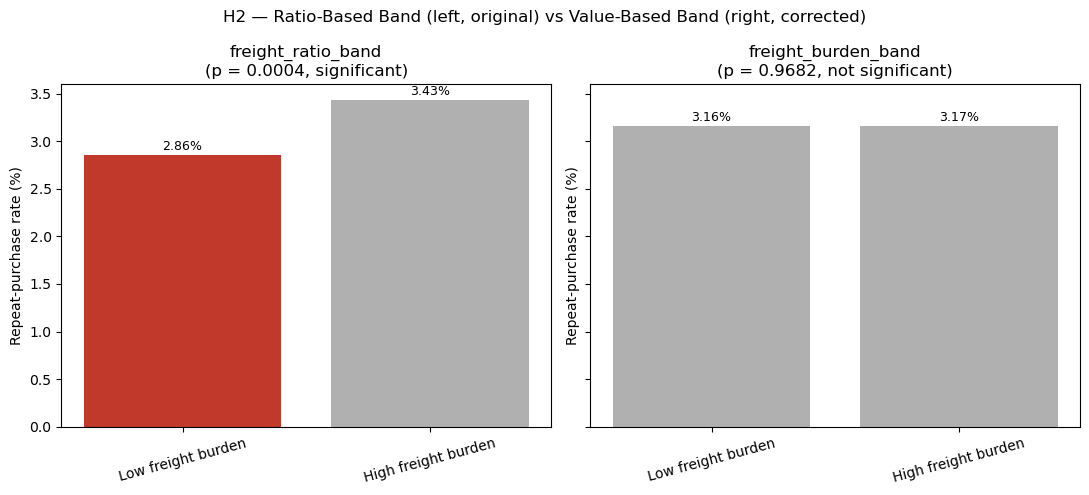

In [18]:
import matplotlib.pyplot as plt

NEUTRAL = "#B0B0B0"
SIGNAL = "#C0392B"

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, (_, row) in zip(axes, h2_band_comparison.iterrows()):
    groups = ["Low freight burden", "High freight burden"]
    rates = [row["low_repeat_rate_pct"], row["high_repeat_rate_pct"]]
    sig = row["p_value"] < 0.05
    # Colour whichever bar is LOWER, only if the test is significant --
    # i.e. highlight the group associated with worse retention.
    lower_idx = int(np.argmin(rates))
    colors = [NEUTRAL, NEUTRAL]
    if sig:
        colors[lower_idx] = SIGNAL

    ax.bar(groups, rates, color=colors)
    ax.set_title(
        f"{row['band_column']}\n"
        f"(p = {row['p_value']:.4f}, "
        f"{'significant' if sig else 'not significant'})"
    )
    ax.set_ylabel("Repeat-purchase rate (%)")
    ax.tick_params(axis="x", rotation=15)
    for i, r in enumerate(rates):
        ax.text(i, r + 0.05, f"{r:.2f}%", ha="center", fontsize=9)

fig.suptitle("H2 — Ratio-Based Band (left, original) vs Value-Based Band (right, corrected)")
plt.tight_layout()
plt.show()


### H2 Correction Check — Result

The two bandings do not meaningfully agree. The ratio-based band shows a statistically significant difference (high − low = +0.576pp, p = 0.0004). The corrected, value-based band shows an essentially zero difference (+0.006pp) that is nowhere near significant (p = 0.968).

This confirms the artifact. The ratio-based H2 result was a mechanical consequence of freight-to-price being confounded with order value, not a genuine relationship — once measured on absolute freight value, the effect disappears entirely rather than merely shrinking.


## 11c. Multicollinearity Check — Before Fitting the Confirmatory Model

The confirmatory logistic regression below uses first-order freight
**value** alongside first-order order **value** as separate predictors.
Because freight and order value are naturally related (heavier/pricier
items cost more to ship), this checks the relationship is a moderate,
safe correlation rather than a near-duplicate that would make the model's
individual coefficients unstable or uninterpretable.


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_data = con.sql("""
    SELECT
        first_order_late_flag,
        first_order_freight,
        first_order_value,
        first_order_installments
    FROM customer_level_featured
    WHERE first_order_late_flag IS NOT NULL
      AND first_order_freight IS NOT NULL
      AND first_order_value IS NOT NULL
      AND first_order_installments IS NOT NULL
""").df()

print("Spearman correlation matrix (candidate LR predictors):")
display(vif_data.corr(method="spearman").round(3))

Xc = add_constant(vif_data)
vif_table = pd.DataFrame({
    "feature": Xc.columns,
    "VIF": [
        variance_inflation_factor(Xc.values, i)
        for i in range(Xc.shape[1])
    ],
})
vif_table = vif_table[vif_table["feature"] != "const"]

print("\nVariance Inflation Factors:")
display(vif_table)

flagged = vif_table[vif_table["VIF"] > 5]
if len(flagged) > 0:
    print(
        f"CAUTION: {list(flagged['feature'])} show VIF > 5. Consider "
        "dropping or combining these predictors before interpreting "
        "individual coefficients below."
    )
else:
    print(
        "All VIF values are below 5. No material multicollinearity concern "
        "for the predictor set used in the confirmatory model below."
    )


Spearman correlation matrix (candidate LR predictors):


,first_order_late_flag,first_order_freight,first_order_value,first_order_installments
first_order_late_flag,1.000,0.044,0.019,0.008
first_order_freight,0.044,1.000,0.469,0.232
first_order_value,0.019,0.469,1.000,0.378
first_order_installments,0.008,0.232,0.378,1.000



Variance Inflation Factors:


,feature,VIF
1,first_order_late_flag,1.000690
2,first_order_freight,1.212704
3,first_order_value,1.292742
4,first_order_installments,1.118191


All VIF values are below 5. No material multicollinearity concern for the predictor set used in the confirmatory model below.


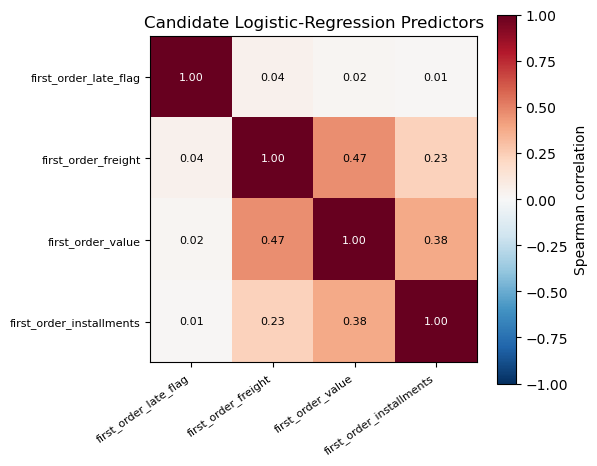

In [20]:
corr_matrix = vif_data.corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns, fontsize=8)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(
            j, i, f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=8,
            color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black",
        )
plt.colorbar(im, label="Spearman correlation")
ax.set_title("Candidate Logistic-Regression Predictors")
plt.tight_layout()
plt.show()

### Multicollinearity Check — Result

Spearman correlation between first-order freight value and first-order
order value is 0.469 -- a moderate, expected relationship (heavier/pricier
items cost more to ship), not a redundancy concern. All VIF values are
below 1.3 (late flag 1.00, freight 1.21, order value 1.29, installments
1.12), well under the conventional threshold of 5. The predictor set is
safe to interpret individually in the confirmatory logistic regression.


# 12. Confirmatory Logistic Regression

A small, interpretable logistic regression is used as a confirmatory check.

The model is secondary to the diagnostic analysis.

Predictors:

- First-order late-delivery flag
- First-order freight value
- First-order order value
- Maximum payment installments

The model estimates the relationship between these first-order variables
and the probability of repeat purchase.

In [21]:
model_data = con.sql("""
SELECT
    is_repeat_customer,
    first_order_late_flag,
    first_order_freight,
    first_order_value,
    first_order_installments
FROM customer_level_featured
WHERE is_repeat_customer IS NOT NULL
  AND first_order_late_flag IS NOT NULL
  AND first_order_freight IS NOT NULL
  AND first_order_value IS NOT NULL
  AND first_order_installments IS NOT NULL
""").df()

X = model_data[
    [
        "first_order_late_flag",
        "first_order_freight",
        "first_order_value",
        "first_order_installments"
    ]
].copy()

y = model_data["is_repeat_customer"].astype(int)

X = sm.add_constant(X)

logit_model = sm.Logit(y, X).fit(disp=False)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:     is_repeat_customer   No. Observations:                93253
Model:                          Logit   Df Residuals:                    93248
Method:                           MLE   Df Model:                            4
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                0.004665
Time:                        08:21:58   Log-Likelihood:                -12780.
converged:                       True   LL-Null:                       -12840.
Covariance Type:            nonrobust   LLR p-value:                 5.913e-25
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -3.5611      0.033   -109.527      0.000      -3.625      -3.497
first_order_late_flag       -0.2102      0.075     -2.788      0.005      -0.358      -0.

## 13. Logistic Regression — Odds Ratios

Convert the regression coefficients into odds ratios with 95% confidence
intervals to make the model easier to interpret.

In [22]:
params = logit_model.params
conf = logit_model.conf_int()

odds_ratio_table = pd.DataFrame({
    "feature": params.index,
    "odds_ratio": np.exp(params.values),
    "ci_low": np.exp(conf[0].values),
    "ci_high": np.exp(conf[1].values),
    "p_value": logit_model.pvalues.values
})

display(odds_ratio_table)

,feature,odds_ratio,ci_low,ci_high,p_value
0,const,0.028408,0.026654,0.030278,0.000000e+00
1,first_order_late_flag,0.810410,0.699086,0.939463,5.299274e-03
2,first_order_freight,1.001322,0.999586,1.003061,1.356941e-01
3,first_order_value,0.999115,0.998829,0.999401,1.313806e-09
4,first_order_installments,1.071645,1.057383,1.086101,4.416241e-24


# 14. Diagnostic Analysis Summary


In [23]:
print("=== DIAGNOSTIC SUMMARY ===")

print(
    f"H1: Late-delivery repeat rate = {late_rate * 100:.2f}%; "
    f"on-time/early repeat rate = {on_time_rate * 100:.2f}%."
)
print(
    f"H1 retention difference (late - on-time/early) = "
    f"{rate_difference * 100:.2f} percentage points."
)
print(
    f"H1 chi-square p-value = {p_value:.6f}; "
    f"odds ratio = {odds_ratio:.3f}."
)

print(
    f"\nH2: High-freight repeat rate = {high_rate * 100:.2f}%; "
    f"low-freight repeat rate = {low_rate * 100:.2f}%."
)
print(
    f"H2 difference (high - low) = {h2_difference * 100:.2f} percentage points."
)
print(
    f"H2 two-proportion p-value = {p_h2:.6f}."
)

print(
    "\nThe delivery vs value-tier analysis is available above for assessing "
    "whether the descriptive delivery gap differs across customer-value tiers."
)

print(
    "\nThe logistic regression is a confirmatory model and should not be "
    "used to replace the primary diagnostic findings."
)

=== DIAGNOSTIC SUMMARY ===
H1: Late-delivery repeat rate = 2.56%; on-time/early repeat rate = 3.13%.
H1 retention difference (late - on-time/early) = -0.58 percentage points.
H1 chi-square p-value = 0.005944; odds ratio = 0.811.

H2: High-freight repeat rate = 3.17%; low-freight repeat rate = 3.16%.
H2 difference (high - low) = 0.01 percentage points.
H2 two-proportion p-value = 0.968213.

The delivery vs value-tier analysis is available above for assessing whether the descriptive delivery gap differs across customer-value tiers.

The logistic regression is a confirmatory model and should not be used to replace the primary diagnostic findings.


## 14a. Persist Diagnostic Findings for Downstream Notebooks

In [24]:
diagnostic_findings = pd.DataFrame([
    {
        "finding": "H1_late_delivery",
        "p_value": p_value,
        "significant": bool(p_value < 0.05),
        "direction": "late_worse" if rate_difference < 0 else "late_better",
        "effect_size": odds_ratio,
        "effect_size_type": "odds_ratio",
    },
    {
        "finding": "H2_freight_ratio_band",
        "p_value": float(h2_band_comparison.iloc[0]["p_value"]),
        "significant": bool(h2_band_comparison.iloc[0]["p_value"] < 0.05),
        "direction": (
            "high_freight_worse"
            if h2_band_comparison.iloc[0]["difference_high_minus_low_pp"] < 0
            else "high_freight_better"
        ),
        "effect_size": float(h2_band_comparison.iloc[0]["difference_high_minus_low_pp"]),
        "effect_size_type": "pp_difference",
    },
    {
        "finding": "H2_freight_value_band_corrected",
        "p_value": float(h2_band_comparison.iloc[1]["p_value"]),
        "significant": bool(h2_band_comparison.iloc[1]["p_value"] < 0.05),
        "direction": (
            "high_freight_worse"
            if h2_band_comparison.iloc[1]["difference_high_minus_low_pp"] < 0
            else "high_freight_better"
        ),
        "effect_size": float(h2_band_comparison.iloc[1]["difference_high_minus_low_pp"]),
        "effect_size_type": "pp_difference",
    },
    {
        "finding": "value_tier_interaction",
        "p_value": float(lr_p_value),
        "significant": bool(lr_p_value < 0.05),
        "direction": "differs_by_tier" if lr_p_value < 0.05 else "no_reliable_difference",
        "effect_size": float(lr_stat),
        "effect_size_type": "likelihood_ratio_statistic",
    },
])

con.register("diagnostic_findings_df", diagnostic_findings)
con.execute("CREATE OR REPLACE TABLE diagnostic_findings AS SELECT * FROM diagnostic_findings_df")
con.unregister("diagnostic_findings_df")

display(diagnostic_findings)
print("\nPersisted to DuckDB table: diagnostic_findings")


,finding,p_value,significant,direction,effect_size,effect_size_type
0,H1_late_delivery,0.005944,True,late_worse,0.811026,odds_ratio
1,H2_freight_ratio_band,0.000363,True,high_freight_better,0.576307,pp_difference
2,H2_freight_value_band_corrected,0.968213,False,high_freight_better,0.006459,pp_difference
3,value_tier_interaction,0.340801,False,no_reliable_difference,3.349585,likelihood_ratio_statistic



Persisted to DuckDB table: diagnostic_findings


In [25]:
results = {
    "h1_descriptive": h1_descriptive,
    "h1_effect": h1_effect,
    "h2_descriptive": h2_descriptive,
    "h2_result": h2_result,
    "h2_quintile_results": h2_quintile_results,
    "delivery_value": delivery_value,
    "gap_by_value": gap_by_value,
    "logistic_odds_ratios": odds_ratio_table,
    "h2_band_comparison": h2_band_comparison,
    "vif_table": vif_table,
    "diagnostic_findings": diagnostic_findings,
}

for name, df in results.items():
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)

print(f"Diagnostic result files saved to: {OUTPUT_DIR}")

con.close()
print("DuckDB connection closed.")

Diagnostic result files saved to: d:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\02_Data\04_Diagnostic
DuckDB connection closed.


# Summary

This notebook formally evaluates the primary diagnostic hypotheses.

H1 evaluates the relationship between first-order delivery lateness and
repeat purchase.

H2 evaluates the relationship between first-order freight burden and repeat
purchase, including a comparison within order-value quintiles.

A secondary delivery vs value-tier analysis and a small logistic regression
provide additional diagnostic and confirmatory evidence.

The results should be carried forward into the final business interpretation
with clear separation between association and causality.